# Линейная регрессия

## Сегодня на практическом занятии:
1. Узнаем, какое количество весов нужно обучать для линейной модели
2. Обучим модель линейной регрессии из sklearn
3. Визуализируем линейную регрессию из sklearn
4. Реализуем свой градиентный спуск для нахождения минимума функции
5. Реализуем свою линейную регрессию с помощью градиентного спуска

In [ ]:
# @title Установка нужных версий библиотек
!pip install scikit-learn pandas matplotlib numpy

--2022-04-20 10:19:08--  https://drive.google.com/uc?export=download&id=1oSFOP0j25OZAuhD8YXxyQXNTdr2lUdtn
Resolving drive.google.com (drive.google.com)... 172.253.115.101, 172.253.115.113, 172.253.115.139, ...
Connecting to drive.google.com (drive.google.com)|172.253.115.101|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-0g-c0-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/hokgac20fp84kbptleaakv3jjnguqrmb/1650449925000/14904333240138417226/*/1oSFOP0j25OZAuhD8YXxyQXNTdr2lUdtn?e=download [following]
--2022-04-20 10:19:08--  https://doc-0g-c0-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/hokgac20fp84kbptleaakv3jjnguqrmb/1650449925000/14904333240138417226/*/1oSFOP0j25OZAuhD8YXxyQXNTdr2lUdtn?e=download
Resolving doc-0g-c0-docs.googleusercontent.com (doc-0g-c0-docs.googleusercontent.com)... 142.250.65.65, 2607:f8b0:4004:832::2001
Connecting to doc-0g-c0-docs.googleusercontent.com (doc-0g-c0

### Получение данных

Будем работать с набором данных для задачи регрессии - данные по предсказанию стоимости недвижимости.

In [ ]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np


data = fetch_california_housing()
X = pd.DataFrame(data["data"], columns=data["feature_names"])
y = data["target"]

X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


## 1. Вводная

В этом пункте вспомним, что такое веса в линейной модели.

### 1.1 Сколько будет обучено свободных весов

Посчитайте, сколько будет создано свободных весов в модели линейная регрессия.

ML-щики говорят `bias`

In [ ]:
# Ваш код здесь

print(
    "Свободных весов будет 1 штука, т.к. для каждой модели идет только один свободный вес - он же коэффициент сдвига"
)

Свободных весов будет 1 штука, т.к. для каждой модели идет только один свободный вес - он же коэффициент сдвига


### 1.2 Сколько будет обучено весов при признаках

Посчитайте, сколько будет создано весов при признаках при обучении линейно модели.

ML-щики говорят просто веса или `weights`

In [ ]:
# Ваш код здесь

print(
    f"Весов при признаках будет {X.shape[1]} штук, т.к. для каждого признака идет свой вес - он же коэффициент наклона"
)

Весов при признаках будет 8 штук, т.к. для каждого признака идет свой вес - он же коэффициент наклона


### 1.3 Обучите линейную модель для предсказания стоимости

In [ ]:
# Ваш код здесь

from sklearn.linear_model import LinearRegression

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

LinearRegression(fit_intercept=False)

### 1.4 Посмотрите, сколько весов вышло и сравните с вашими ответами

In [ ]:
# Ваш код здесь

print(f"Весов при признаках вышло {len(model.coef_)} штук, как и было подсчитано выше")

Весов при признаках вышло 8 штук, как и было подсчитано выше


In [ ]:
print(
    f"Свободных весов вышло {np.array([model.intercept_]).shape[0]} штука, как и было подсчитано выше"
)

Свободных весов вышло 1 штука, как и было подсчитано выше


## 2. Получение предсказаний линейной модели

В этом пункте вспомним, как получать предсказания линейной моделью.

### 2.1 Получите предсказание для одного объекта через метод модели

In [ ]:
# Ваш код здесь

model.predict(X[:1])

array([4.09839978])

### 2.2 Получите предсказание для одного объекта через полученные веса

In [ ]:
# Ваш код здесь

np.sum(model.coef_ * X[:1].values) + model.intercept_

4.098399778940821

### 2.3 Посмотрите ошибку MSE на предсказаниях модели

In [ ]:
# Ваш код здесь

from sklearn.metrics import mean_squared_error

mean_squared_error(y, model.predict(X))

0.6042095028861159

## 3. Визуализация линейной модели

В этом пункте провизуализируем линейную модель для одного признака.

### 3.1. Возьмите только один первый признак из данных и первые 1000 объектов

Назовите данный датафрейм `small_X`, а истинные значения `small_y`

In [ ]:
# Ваш код здесь

small_X = X[["MedInc"]].iloc[:1000]
small_y = y[:1000]

### 3.2. Обучите на этих данных линейную модель

In [ ]:
# Ваш код здесь

model = LinearRegression()
model.fit(small_X, small_y)

LinearRegression()

### 3.3. Отобразите на графике обученную линейную регрессию

Добавьте на график точки из обучения в виде точечного графика

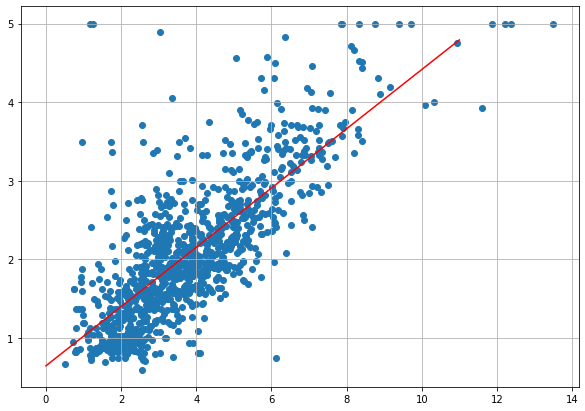

In [ ]:
# Ваш код здесь

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
x = np.arange(0, 12)
model_line = model.coef_ * x + model.intercept_
plt.plot(x, model_line, "-r")
plt.scatter(small_X, small_y)
plt.grid()

### 3.4 Посмотрите ошибку MSE на предсказаниях модели

In [ ]:
# Ваш код здесь

from sklearn.metrics import mean_squared_error

mean_squared_error(small_y, model.predict(small_X))

0.32656055110726806

## 4. Градиентный спуск

В этом пункте реализуем свой градиентный спуск.

### 4.1. Найдите градиент функции $z = 2x + y^2$

Ваш градиент здесь


$\nabla z = (\frac{\partial z}{\partial x}, \frac{\partial z}{\partial y}) = (x, 2y)$

WTF??? $\frac{\partial z}{\partial x} = 2$

из определения производной: 
$$\frac{\partial f(x)}{\partial x} = \lim_{h \to 0} \frac{f(x + h) - f(x)}{h}$$

получаем следующее (на предел забью, спойлер - всё сократится)
$$\frac{\partial z}{\partial x} = \frac{f(x + h) - f(x)}{h} = \frac{2(x + h) + y^2 - (2x + y^2)}{h} = \frac{2h + z - z}{h} = \frac{2h}{h} = 2$$

### 4.2. Реализуйте функцию для подсчета $z = 0.25 x^2 + 5$

In [ ]:
# Ваш код здесь


def func(x):
    return 0.25 * x**2 + 5

### 4.3. Реализуйте функцию для подсчета градиента $z = 0.25 x^2 + 5$

In [ ]:
# Ваш код здесь


def gr_func(x):
    return 0.5 * x

### 4.4. Отрисуйте на графике функцию из пункта 4.2.

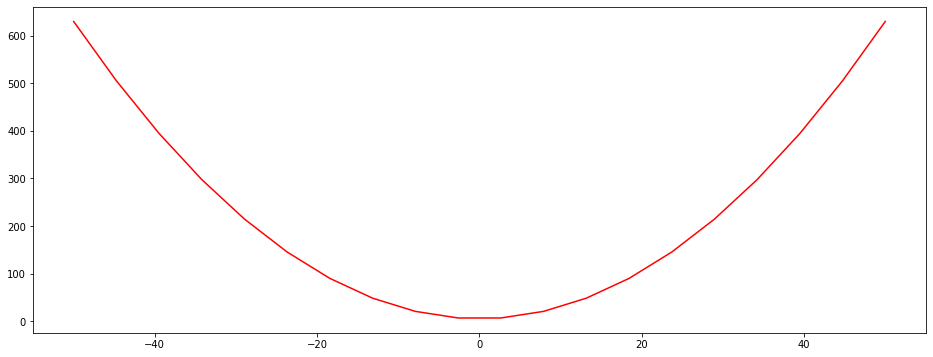

In [ ]:
# Ваш код здесь

D = 50

x = np.linspace(-D, +D, 20)
Y = func(x)

plt.figure(figsize=(16, 6))
plt.plot(x, Y, "r", label="Y(X)");

### 4.5. Задайте начальную точку равную -15 и посчитайте в ней градиент

In [ ]:
# Ваш код здесь

start_point = -15
grad = gr_func(start_point)

Вообще, ради математики (понтов) можно посчитать то же самое, но с использованием определения градиента:

In [ ]:
h = 1e-8
my_grad = (func(start_point + h) - func(start_point)) / h
np.allclose(my_grad, grad)

### 4.5. Сделайте один шаг градиентного спуска и получите следующую точку для подсчета градиента

In [ ]:
# Ваш код здесь

curr_point = start_point

next_point = curr_point - grad

next_point

-7.5

### 4.6. Оформите цикл из 10 шагов градиентного спуска

In [ ]:
# Ваш код здесь

# первоначальное точка
start_point = -15

# начальная точка
next_point = start_point

points = []
points.append(next_point)

# количество итерация
n = 10
for i in range(n):
    current_point = next_point

    # движение в негативную сторону вычисляемого градиента
    next_point = current_point - gr_func(current_point)
    points.append(next_point)
    # print(next_point)

    # остановка когда достигнута необходимая степень точности
    print(f"Итерация: {i}")
    print(f"Текущая точка {current_point}| Следующая точка {next_point}")
    print("--------------------------------------------------------")

Итерация: 0
Текущая точка -15| Следующая точка -7.5
--------------------------------------------------------
Итерация: 1
Текущая точка -7.5| Следующая точка -3.75
--------------------------------------------------------
Итерация: 2
Текущая точка -3.75| Следующая точка -1.875
--------------------------------------------------------
Итерация: 3
Текущая точка -1.875| Следующая точка -0.9375
--------------------------------------------------------
Итерация: 4
Текущая точка -0.9375| Следующая точка -0.46875
--------------------------------------------------------
Итерация: 5
Текущая точка -0.46875| Следующая точка -0.234375
--------------------------------------------------------
Итерация: 6
Текущая точка -0.234375| Следующая точка -0.1171875
--------------------------------------------------------
Итерация: 7
Текущая точка -0.1171875| Следующая точка -0.05859375
--------------------------------------------------------
Итерация: 8
Текущая точка -0.05859375| Следующая точка -0.029296875
----

### 4.7. Визуализируйте шаги градиентного спуска на графике

Так же отрисуйте исходную функцию.

минимум -0.0146484375, количество затраченных итераций: 9


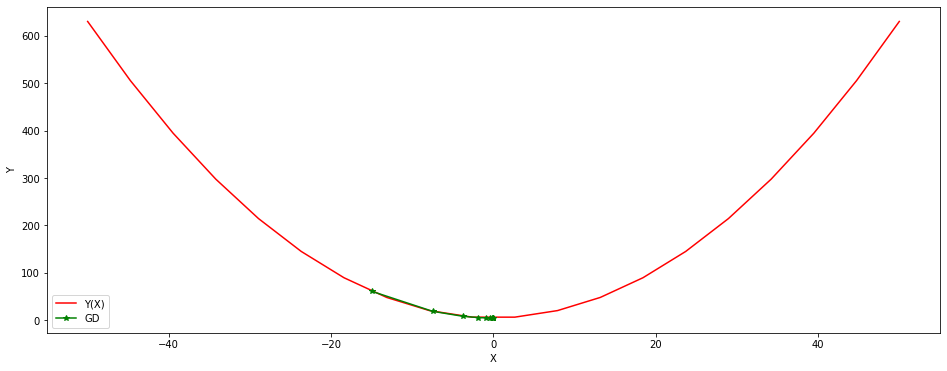

In [ ]:
# Ваш код здесь

plt.figure(figsize=(16, 6))
plt.plot(x, Y, "r", label="Y(X)")

print(f"минимум {next_point}, количество затраченных итераций: {i}")
X_grad = np.array(points)
plt.plot(X_grad, func(X_grad), "-*g", label="GD")
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

## 5. Многомерная линейная регрессия

В это пункте реализуем свою линейную регрессию для датафрейма small_X

#### 5.1 Реализуйте функцию для подсчета MSE

Функция на вход принимает матрицу `X`, вектор весов `w` и истинные значения `y`

In [ ]:
# Ваш код здесь


def mse(X, w, y):
    pred = X @ w
    return np.mean((y - pred) ** 2)

#### 5.2 Реализуйте функцию для подсчета градиента MSE

Функция на вход принимает матрицу `X`, вектор весов `w` и истинные значения `y`.

$MSE = (\frac{1}{n}) * \sum_{n}(y_{true} - y_{pred})^2$

$\frac{\partial (MSE)}{\partial(w)} = \frac{\partial((\frac{1}{n}) * \sum_{n}(y_{true} - y_{pred})^2)}{\partial(w)}$

По правилу производной сложной функции:

$u(v)` = u`(v) * v`$

$\frac{\partial (y_{true} - (Xw +b))^2}{\partial(w)} = 2 * (y_{true} - (Xw + b)) * (\frac{\partial(y_{true} - (Xw + b))}{\partial(w)})$

$\frac{\partial (y_{true})}{\partial(w)} = 0; \frac{\partial (f + g)}{\partial(x)} = \frac{\partial (f)}{\partial(x)} + \frac{\partial (g)}{\partial(x)} => \frac{\partial(y_{true} - (Xw + b))}{\partial(w)} = 0-\frac{\partial(Xw + b)}{\partial(w)} = -X$

Отсюда градиент для одного веса будет равен:

$\frac{\partial (MSE)}{\partial(w)} = -\frac{2}{n} * (y_{true} - y_{pred})X = -\frac{2}{n} * X^T(y_{true} - y_{pred})$

На сумму забьём, там за счёт матричного умножения она происходит. 

Для bias (b) будет то же самое, но только без матричного умножения на X


In [ ]:
# Ваш код здесь


def gr_mse(X, w, y):
    pred = X @ w
    return -2 / len(X) * ((y - pred) @ (X))

#### 5.3 Инициализируйте веса для признаков

Вспомните и про свободный вес, что нужно сделать с данными, чтобы свободный вес не стоял отдельно.

In [ ]:
# Ваш код здесь

small_X["for_intercept"] = 1
small_X.head()

,MedInc,for_intercept
0,8.3252,1
1,8.3014,1
2,7.2574,1
3,5.6431,1
4,3.8462,1


In [ ]:
weights = np.random.randn(small_X.shape[1])
weights

array([-0.06774687,  0.66589022])

#### 5.4 Запустить цикл обучения через градиентный спуск для линейной регрессии


In [ ]:
# @title Подсказка 1
# Вспомните про шаг обучения, если вам кажется, что он нужен

In [ ]:
# @title Подсказка 2
# Возможно потребуется больше итераций

In [ ]:
# Ваш код здесь

def train(weights: np.ndarray, small_X: np.ndarray, small_y: np.ndarray, criteria: Callable | None = None) -> None:
    if criteria is None:
        criteria = lambda: False

    # размер шага (learning rate)
    learning_rate = 0.01
    next_weights = weights
    # количество итерация
    n = 10000
    for i in range(n):
        cur_weights = next_weights

        # движение в негативную сторону вычисляемого градиента
        next_weights = cur_weights - learning_rate * gr_mse(
            small_X.values, cur_weights, small_y
        )

        if (i % 100) == 0:
            print(f"Итерация: {i}")
            print(f"MSE {mse(small_X.values, cur_weights, small_y)}")
            print("--------------------------------------------------------")

        if criteria():
            break

train(weights, small_X, small_y)

Итерация: 0
MSE 24.765245051235198
--------------------------------------------------------
Итерация: 100
MSE 1.4606594011340246
--------------------------------------------------------
Итерация: 200
MSE 0.8920457993219714
--------------------------------------------------------
Итерация: 300
MSE 0.6085232441660787
--------------------------------------------------------
Итерация: 400
MSE 0.4671530078123303
--------------------------------------------------------
Итерация: 500
MSE 0.39666287091395974
--------------------------------------------------------
Итерация: 600
MSE 0.3615150241810908
--------------------------------------------------------
Итерация: 700
MSE 0.3439895775822516
--------------------------------------------------------
Итерация: 800
MSE 0.33525102580628935
--------------------------------------------------------
Итерация: 900
MSE 0.3308938023420821
--------------------------------------------------------
Итерация: 1000
MSE 0.3287212001988685
----------------------

#### 5.5 Реализуйте критерий останова по ошибке

Если ошибка с текущей итерации меньше, чем на следующей итерации, то можно выходить из цикла обучения


In [ ]:
# Ваш код здесь

def early_stopping(small_X, small_y, cur_weights, next_weights) -> bool:
    return mse(small_X.values, cur_weights, small_y) < mse(
        small_X.values, next_weights, small_y
    )

train(weights, small_X, small_y, early_stopping)

Итерация: 0
MSE 3.829280734662681
--------------------------------------------------------
Итерация: 100
MSE 0.32764429752875185
--------------------------------------------------------
Итерация: 200
MSE 0.327100929588509
--------------------------------------------------------
Итерация: 300
MSE 0.3268299950447054
--------------------------------------------------------
Итерация: 400
MSE 0.3266949014523355
--------------------------------------------------------
Итерация: 500
MSE 0.3266275409805286
--------------------------------------------------------
Итерация: 600
MSE 0.326593953649831
--------------------------------------------------------
Итерация: 700
MSE 0.326577206308948
--------------------------------------------------------
Итерация: 800
MSE 0.3265688557368476
--------------------------------------------------------
Итерация: 900
MSE 0.3265646919681101
--------------------------------------------------------
Итерация: 1000
MSE 0.3265626158265128
---------------------------

## Резюме

Сегодня на практическом занятии:
1. Узнали, какое количество весов нужно обучать для линейной модели
2. Обучили модель линейной регрессии из sklearn
3. Визуализировали линейную регрессию из sklearn
4. Реализовали свой градиентный спуск для нахождения минимума функции
5. Реализовали свою линейную регрессию с помощью градиентного спуска